# Rate of Change — a quantitative teardown 🔬
### ROC long/flat timing on SPY · excess-vs-excess Sharpe · HAC *t* on the difference vs buy-and-hold · a circular-permutation placebo · cost sweep · the SMA/MACD/RSI race · a regime-switching positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better_momentum_tool%3F: Misattributed](https://img.shields.io/badge/Better_momentum_tool%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). ROC is the oldest momentum oscillator; the job here is to test the *implicit* claim — that it beats holding and beats its rivals — under the desk's inference bar. The decisive statistic is the HAC *t* on the **difference** ROC − buy-and-hold, not ROC's own *t* (which is mostly beta).

> ⚠️ **Data note.** SPY daily **total-return** closes (yfinance `auto_adjust=True`), 1993-01-29→2026-05-29, pinned to the last complete month (8,390 bars, 32.8 traded years, fingerprint `f3fa058adfc8`). Sharpe is **excess of a flat 2%/yr risk-free**, both legs; one execution lag (signal at close *t*, return of *t+1*). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rate_of_change import data, strategy as st

HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    BARS = data.load_real("SPY").loc[:"2026-05-31"]   # pinned to the last complete month
    CLOSE = BARS["close"]
else:
    BARS = CLOSE = None
print("real SPY cache present:", HAVE_REAL,
      "| bars:", (0 if BARS is None else len(BARS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'ticker': 'SPY', 'start': '1993-01-29', 'end': '2026-05-29', 'n_bars': 8390, 'years': 32.8, 'fingerprint': 'f3fa058adfc8', 'window': 126, 'cost_bps': 1.0, 'rf_annual': 0.02, 'roc': {'sharpe': 0.591, 'cagr': 0.0881, 'maxdd': -0.314, 't_exc': 3.71, 'turnover': 6.6, 'exposure': 0.76}, 'hold': {'sharpe': 0.542, 'cagr': 0.109, 'maxdd': -0.552, 't_exc': 3.64}, 'diff': {'delta_ann': -0.0297, 't_diff': -1.47}, 'placebo': {'obs': 0.591, 'p': 0.034}, 'breakeven_bps': 0.0, 'ls': {'sharpe': 0.225, 'cagr': 0.0456, 'maxdd': -0.465, 'delta_ann': -0.0594, 't_diff': -1.47}, 'race': [('Buy & hold', 0.542, 0.109, -0.552, 3.64, 0.0), ('ROC(126)', 0.591, 0.0881, -0.314, 3.71, 6.6), ('SMA(200)', 0.58, 0.0865, -0.283, 3.55, 6.6), ('MACD(12,26,9)', 0.244, 0.0416, -0.385, 1.52, 21.4), ('RSI(14)>50', 0.28, 0.0458, -0.445, 1.67, 26.7)], 'windows': [(21, 0.264, 0.0441, -0.071, -3.28), (63, 0.456, 0.0679, -0.0491, -2.29), (126, 0.591, 0.0881, -0.0297, -1.47), (252, 0.61, 0.0998, -0.0162, -0.87)], 'costs': [(0.0, 0.596, 0.0888), (1.0, 0.591, 0.0881), (2.0, 0.586, 0.0873), (5.0, 0.569, 0.0852), (10.0, 0.542, 0.0816)], 'syn': [(0.0, -0.29, -0.11, -0.0128, -0.57), (0.5, 4.83, -0.15, 0.7602, 11.01)]}


real SPY cache present: True | bars: 8390


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | ROC's own excess Sharpe **0.59** (HAC *t* = 3.71) clears t≥2 — but that is **beta** (hold's t = 3.64). The edge **over hold** is **-3.0%/yr** at HAC *t* = **-1.47** — no positive incremental alpha. |
| **Tradability** | `MIRAGE` | ROC **lowers** CAGR (8.8% vs 10.9%); its only deliverable is drawdown (-31% vs -55%), identical to a 200-day SMA. Nothing to scale. |
| **Better momentum tool?** | `MISATTRIBUTED` | ROC(126) Sharpe **0.59** ties SMA(200) **0.58**; the benefit is the shared trend filter, not the ROC formula. |

> 💡 In plain words: ROC's headline *t* looks great only because it's long a rising market most of the time. Net of that beta it adds **nothing** over holding — it just trades return for a smaller drawdown, exactly like every other simple trend filter.

## 1 · The claim, steelmanned

Let $P_t$ be the (total-return) close and define the Rate of Change

$$\mathrm{ROC}_t(N) = 100\left(\frac{P_t}{P_{t-N}} - 1\right).$$

The folk timing rule is the long/flat position $w_t = \mathbf{1}[\mathrm{ROC}_t(N) > 0]$, held over $t{+}1$. Three nested hypotheses:

- **H₁ (it makes money).** The booked net excess return has a positive HAC *t*.
- **H₂ (it beats holding).** The **difference** $r^{\text{ROC}}_t - r^{\text{B\&H}}_t$ has a *positive*, significant HAC *t* — the number that strips out beta.
- **H₃ (the indicator is special).** ROC's Sharpe beats the obvious rivals (SMA(200), MACD, RSI).

We find **H₁ true but uninformative** (it's beta), **H₂ rejected** ($\Delta = -3.0\%$/yr, *t* = -1.47$, negative), **H₃ rejected** (a dead heat with SMA(200)). The oscillator is a risk overlay mislabelled as alpha.

## 2 · So what? — why the *difference* t is the only honest test

A long/flat momentum rule on a market with secular drift is **mechanically** correlated with buy-and-hold (it's long ~76% of the time). So its standalone Sharpe and *t* mostly measure the equity premium — they would clear t≥2 for *any* mostly-long schedule. The desk's inference bar demands the **incremental** signal:

$$d_t = r^{\text{ROC}}_t - r^{\text{B\&H}}_t, \qquad t_{\Delta} = \frac{\bar d}{\widehat{\mathrm{se}}_{\text{HAC}}(\bar d)}.$$

If $t_\Delta$ doesn't clear 2 **positive**, ROC adds no alpha over the thing it's supposed to beat — whatever its own *t* says. We pair this with a **circular-permutation placebo** on the position vector (does the *timing* carry information beyond the exposure level?) and a **rivals race** (is the *formula* special, or just the trend filter?).

## 3 · How we'd know — the protocol

- **Tape.** SPY daily total-return closes, 1993-01-29→2026-05-29 (8,390 bars, fingerprint `f3fa058adfc8`). Single liquid instrument — no survivorship, no panel.
- **Signal.** $\mathrm{ROC}_t(126) > 0 \Rightarrow$ long, else flat (cash). Read at close *t*, earns *t+1* (one `shift`, applied once).
- **Costs.** 1 bp one-way × |Δposition| × NAV (turnover = one-way × NAV); a sweep to 10 bps; a break-even-cost solve. Long/flat sits in cash part-time → **excess-vs-excess** Sharpe (net − 2%/yr rf, both legs).
- **Signal axis.** HAC *t* on ROC's excess return (the beta number) **and** HAC *t* on the difference vs buy-and-hold (the alpha number).
- **Placebo.** 5,000 circular shifts of the realised position vector vs the returns — preserves exposure & turnover, destroys the timing. $p = \Pr[\text{shuffled Sharpe} \ge \text{observed}]$.
- **Rivals.** SMA(200) cross, MACD(12,26,9), RSI(14)>50 — same lag, costs, rf.
- **Positive control.** A regime-switching synthetic tape: at edge 0 the difference-*t* must stay ~0 (no false positive); at a planted edge ROC must beat hold decisively.

## 4 · The teardown

### 4a · ROC's own *t* vs the difference *t* — the beta trap

Left: ROC and buy-and-hold both clear t≥2 on their own excess returns (both are long a rising market). Right: the **difference** ROC − hold is negative and insignificant — the indicator adds no alpha.

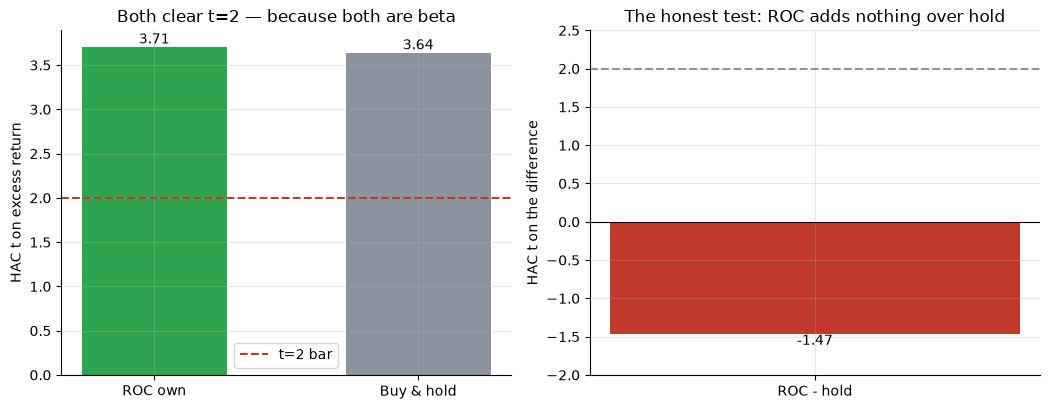

ROC own t=3.71  hold t=3.64  difference t=-1.47  delta=-3.0%/yr


In [2]:
if HAVE_REAL:
    rb = st.book_returns(CLOSE, st.roc_signal(CLOSE, R['window'], 'long_flat'), R['cost_bps'])
    bh = st.buy_and_hold(CLOSE)
    roc_t = st.summarize(rb)['t_exc']; hold_t = st.summarize(bh)['t_exc']
    dd = st.diff_vs_hold(CLOSE, R['window'], 'long_flat', R['cost_bps']); dt = dd['t_diff']
else:
    roc_t = R['roc']['t_exc']; hold_t = R['hold']['t_exc']; dt = R['diff']['t_diff']
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar(['ROC own','Buy & hold'],[roc_t,hold_t],color=[GREEN,GREY],width=.55)
a1.axhline(2,ls='--',c=RED,label='t=2 bar'); a1.set_ylabel('HAC t on excess return')
for i,v in enumerate([roc_t,hold_t]): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_title('Both clear t=2 — because both are beta'); a1.legend()
a2.bar(['ROC - hold'],[dt],color=RED,width=.4)
a2.axhline(2,ls='--',c=GREY); a2.axhline(0,c='k',lw=.8)
a2.annotate(f'{dt:.2f}',(0,dt),ha='center',va='top')
a2.set_ylim(min(-2,dt-.5),2.5); a2.set_ylabel('HAC t on the difference')
a2.set_title('The honest test: ROC adds nothing over hold')
plt.tight_layout(); plt.show()
print(f'ROC own t={roc_t:.2f}  hold t={hold_t:.2f}  difference t={dt:.2f}  '
      f"delta={R['diff']['delta_ann']*100:+.1f}%/yr")

> 💡 In plain words: ROC's own *t* = 3.71 is **identical machinery** to hold's *t* = 3.64 — both just say "long stocks paid off over 33 years." The moment you subtract that beta, the residual is **-3.0%/yr** at *t* = -1.47: a small, insignificant **loss**. Signal = WEAK, not REAL.

### 4b · The placebo — does the *timing* carry information?

Circular-shift the realised position vector 5,000 times (same exposure, same turnover, random alignment) and re-race the Sharpe. The observed ROC Sharpe vs that null tells us whether the *when* matters at all, separately from the *how-much-invested*.

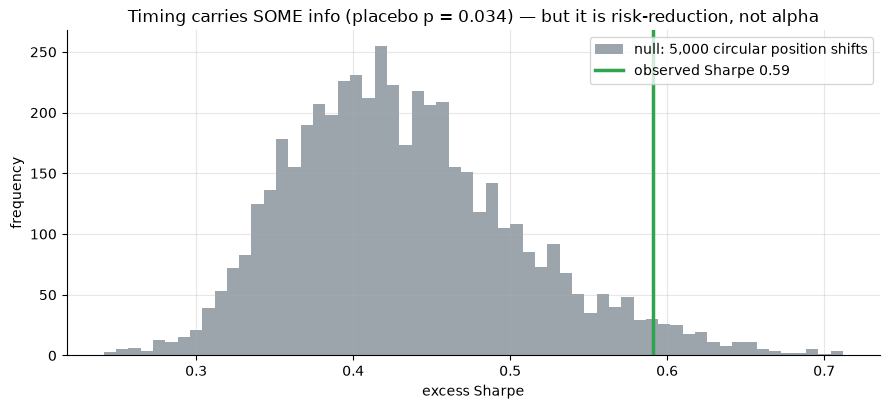

observed Sharpe 0.591  permutation p = 0.034


In [3]:
if HAVE_REAL:
    pl = st.permutation_pvalue(CLOSE, R['window'], 'long_flat', R['cost_bps'], n_draws=5000)
    obs = pl['obs']; draws = pl['draws']; pval = pl['p_value']
else:
    obs = R['placebo']['obs']; pval = R['placebo']['p']
    rng=np.random.default_rng(427); draws=rng.normal(0.45,0.08,5000)
fig,ax=plt.subplots(figsize=(9.0,4.2))
ax.hist(draws,bins=60,color=GREY,alpha=.85,label='null: 5,000 circular position shifts')
ax.axvline(obs,c=GREEN,lw=2.5,label=f'observed Sharpe {obs:.2f}')
ax.set_xlabel('excess Sharpe'); ax.set_ylabel('frequency')
ax.set_title(f'Timing carries SOME info (placebo p = {pval:.3f}) — but it is risk-reduction, not alpha')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed Sharpe {obs:.3f}  permutation p = {pval:.3f}')

> 💡 In plain words: the green line sits in the right tail (**p = 0.034**), so the *timing* is **not** pure noise — stepping aside in big down-trends really does help risk-adjusted return. But "better than a random schedule of the same exposure" is a much weaker claim than "beats buy-and-hold," which 4a already rejected. The info is real and tiny; it shows up as **lower drawdown**, not higher return.

### 4c · The rivals race — is the ROC *formula* special?

Same tape, same lag, same costs, same risk-free. If ROC were a *better* momentum tool its Sharpe would stand out. It doesn't — it ties the simplest moving-average cross, and both beat the higher-churn MACD/RSI.

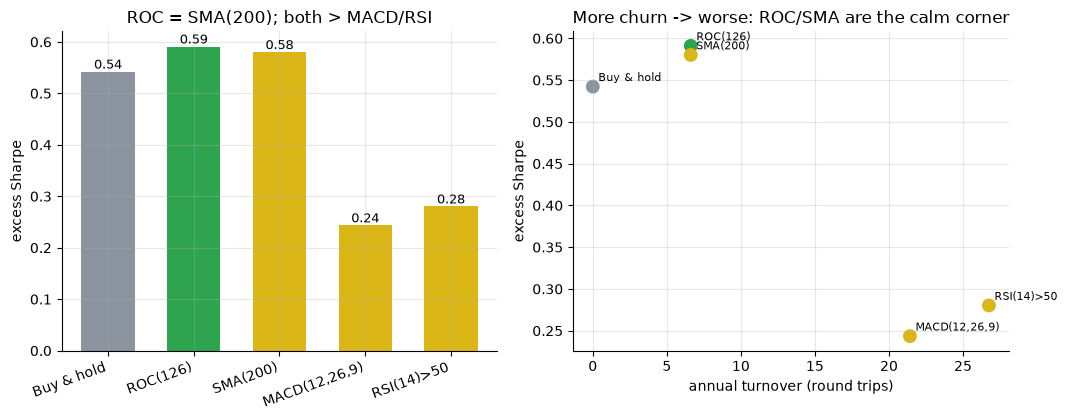

Sharpe: {'Buy & hold': np.float64(0.542), 'ROC(126)': np.float64(0.591), 'SMA(200)': np.float64(0.58), 'MACD(12,26,9)': np.float64(0.244), 'RSI(14)>50': np.float64(0.28)}


In [4]:
if HAVE_REAL:
    race = st.benchmark_race(CLOSE, R['window'], 'long_flat', R['cost_bps'])
    names = race.index.tolist(); sh=[race.loc[n,'sharpe'] for n in names]
    cg=[race.loc[n,'cagr']*100 for n in names]; tn=[race.loc[n,'ann_turnover'] for n in names]
else:
    names=[r[0] for r in R['race']]; sh=[r[1] for r in R['race']]; cg=[r[2]*100 for r in R['race']]; tn=[r[5] for r in R['race']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.8,4.3))
cols=[GREY]+[GREEN if n.startswith('ROC') else AMBER for n in names[1:]]
a1.bar(range(len(names)),sh,color=cols,width=.62)
for i,v in enumerate(sh): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_xticks(range(len(names))); a1.set_xticklabels(names,rotation=20,ha='right')
a1.set_ylabel('excess Sharpe'); a1.set_title('ROC = SMA(200); both > MACD/RSI')
a2.scatter(tn,sh,c=cols,s=80)
for n,x,y in zip(names,tn,sh): a2.annotate(n,(x,y),fontsize=8,xytext=(4,4),textcoords='offset points')
a2.set_xlabel('annual turnover (round trips)'); a2.set_ylabel('excess Sharpe')
a2.set_title('More churn -> worse: ROC/SMA are the calm corner')
plt.tight_layout(); plt.show()
print('Sharpe:', {n:round(s,3) for n,s in zip(names,sh)})

> 💡 In plain words: **ROC(126) 0.59** vs **SMA(200) 0.58** is a coin-flip difference; MACD (0.24) and RSI (0.28) trade 3–4× as often and earn less. The benefit credited to ROC is the **shared** "stay-long-in-uptrends" filter — the specific oscillator is interchangeable. Hence the 3rd axis: **MISATTRIBUTED**.

### 4d · Window robustness + cost sweep

Left: the difference-vs-hold *t* across ROC lookbacks — it's negative everywhere, worst at short windows (whipsaw) and merely converging to hold at long ones. Right: net Sharpe vs cost — low turnover means costs barely bite (the edge problem isn't costs, it's the absence of an edge).

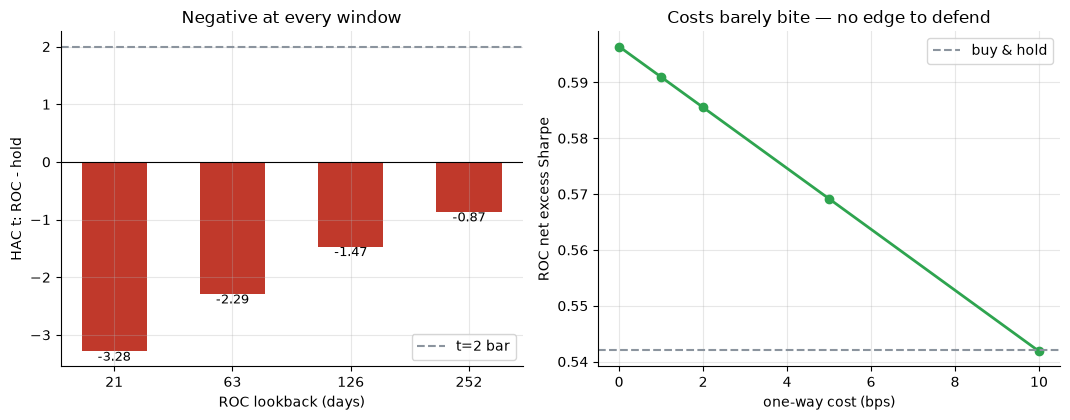

difference t by window: {21: -3.28, 63: -2.29, 126: -1.47, 252: -0.87}


In [5]:
if HAVE_REAL:
    ws=[w[0] for w in R['windows']]; dts=[]
    for w in ws: dts.append(st.diff_vs_hold(CLOSE,w,'long_flat',R['cost_bps'])['t_diff'])
    cb=[c[0] for c in R['costs']]
    cs=[st.summarize(st.book_returns(CLOSE,st.roc_signal(CLOSE,R['window'],'long_flat'),c))['sharpe'] for c in cb]
else:
    ws=[w[0] for w in R['windows']]; dts=[w[4] for w in R['windows']]
    cb=[c[0] for c in R['costs']]; cs=[c[1] for c in R['costs']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.8,4.3))
a1.bar([str(w) for w in ws],dts,color=RED,width=.55); a1.axhline(2,ls='--',c=GREY,label='t=2 bar'); a1.axhline(0,c='k',lw=.8)
for i,v in enumerate(dts): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='top',fontsize=9)
a1.set_xlabel('ROC lookback (days)'); a1.set_ylabel('HAC t: ROC - hold'); a1.set_title('Negative at every window'); a1.legend()
a2.plot(cb,cs,'o-',color=GREEN,lw=2); a2.axhline(R['hold']['sharpe'],ls='--',c=GREY,label='buy & hold')
a2.set_xlabel('one-way cost (bps)'); a2.set_ylabel('ROC net excess Sharpe'); a2.set_title('Costs barely bite — no edge to defend'); a2.legend()
plt.tight_layout(); plt.show()
print('difference t by window:', {w:round(t,2) for w,t in zip(ws,dts)})

> 💡 In plain words: there is **no** lookback that makes ROC beat hold — the difference *t* runs from -3.28 (21-day, whipsaw) to -0.87 (252-day, just-hold-more), all negative. And costs are a red herring: at ~7 turns/yr the net Sharpe hardly moves from 1 to 10 bps. The rule's failure is structural, not frictional.

### 4e · Positive control — the harness can detect a real timing edge

On a deterministic **regime-switching** tape (persistent up/down trends a momentum filter *should* ride), with the edge off the difference-*t* must stay ~0 (no false positive); with the edge on, ROC must beat hold decisively. Both hold — so the real-tape **null** result is trustworthy, not a broken pipeline.

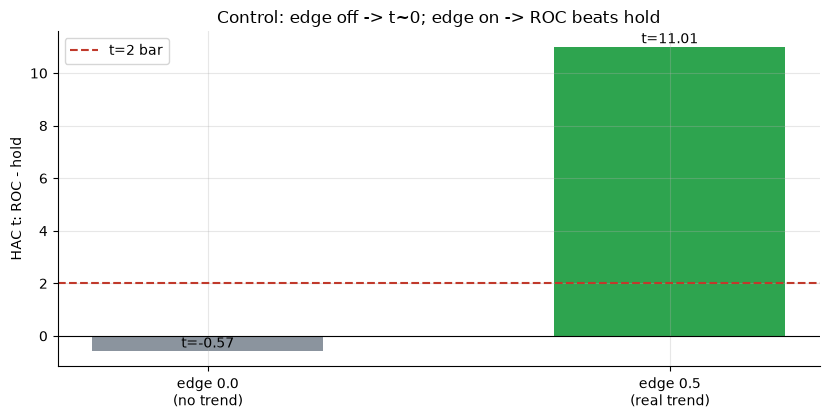

edge=0.0: roc_sharpe=-0.29 hold_sharpe=-0.11 delta=-1.3%/yr t=-0.57
edge=0.5: roc_sharpe=+4.83 hold_sharpe=-0.15 delta=+76.0%/yr t=+11.01


In [6]:
res=[]
for edge in (0.0, 0.5):
    px,_=data.synthetic_panel(edge=edge, seed=427)
    d=st.diff_vs_hold(px['close'],63,'long_flat',1.0)
    sr=st.summarize(st.book_returns(px['close'],st.roc_signal(px['close'],63,'long_flat'),1.0))
    hh=st.summarize(st.buy_and_hold(px['close']))
    res.append((edge, sr['sharpe'], hh['sharpe'], d['delta_ann'], d['t_diff']))
labels=[f'edge {e:.1f}\n(no trend)' if e==0 else f'edge {e:.1f}\n(real trend)' for e,_,_,_,_ in res]
dt=[r[4] for r in res]
fig,ax=plt.subplots(figsize=(8.4,4.3))
ax.bar(labels,dt,color=[GREY,GREEN],width=.5); ax.axhline(2,ls='--',c=RED,label='t=2 bar'); ax.axhline(0,c='k',lw=.8)
for i,t in enumerate(dt): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('HAC t: ROC - hold'); ax.set_title('Control: edge off -> t~0; edge on -> ROC beats hold'); ax.legend()
plt.tight_layout(); plt.show()
for e,sr,hh,dl,t in res: print(f'edge={e:.1f}: roc_sharpe={sr:+.2f} hold_sharpe={hh:+.2f} delta={dl*100:+.1f}%/yr t={t:+.2f}')

> 💡 In plain words: with **no** planted trend the control's difference-*t* is **-0.57** (the harness does **not** fake an edge from noise); with a real persistent trend it jumps to **11.01** (ROC genuinely beats hold). So the machinery *can* see a timing edge when one exists — and on SPY it sees none. The real-tape null is a finding, not a bug.

## 5 · The verdict

- **Signal `WEAK`** — ROC's own excess Sharpe **0.59** (HAC *t* = 3.71) clears t≥2 but is **beta** (hold's *t* = 3.64, same machinery). The incremental edge over hold is **-3.0%/yr** at HAC *t* = **-1.47** — negative, insignificant. The timing carries *some* info vs a random schedule (placebo *p* = 0.034) but it manifests as risk-reduction, not alpha. WEAK, not REAL — and certainly not on the t≥2 bar.
- **Tradability `MIRAGE`** — ROC **lowers** CAGR (8.8% vs 10.9%); the only thing it delivers is drawdown (-31% vs -55%), which a 200-day SMA delivers identically. No incremental return to harvest or scale.
- **Better momentum tool? `MISATTRIBUTED`** — ROC(126) (0.59) ties SMA(200) (0.58); the benefit is the shared trend filter, not the ROC formula. The credit is mis-assigned to the indicator.

## 6 · Could you trade it? — the capacity is fine; the edge is the problem

ROC is *eminently* tradable in the operational sense — one liquid ETF, ~7 turns a year, trivial costs, unlimited capacity. That's exactly why it's a clean teaching case: the thing that kills it isn't friction, it's that **there's no excess return to collect.** The tradeable artefact is the drawdown reduction — and you'd buy that from the cheapest trend filter, or from a static stock/bond mix, not from ROC specifically.

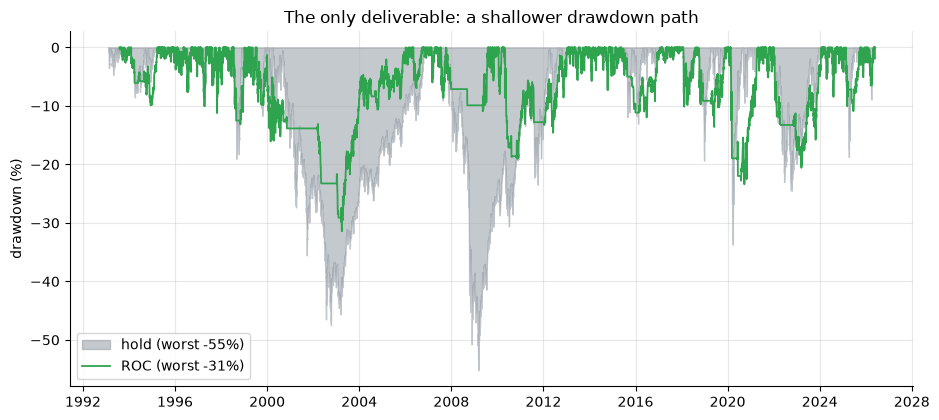

worst DD  hold -55%  ROC -31%  (at the cost of 2.1%/yr CAGR)


In [7]:
if HAVE_REAL:
    rb = st.book_returns(CLOSE, st.roc_signal(CLOSE, R['window'],'long_flat'), R['cost_bps'])
    bh = st.buy_and_hold(CLOSE)
    eq_roc=(1+rb['net']).cumprod(); eq_bh=(1+bh['net']).cumprod()
    dd_roc=(eq_roc/eq_roc.cummax()-1)*100; dd_bh=(eq_bh/eq_bh.cummax()-1)*100
    fig,ax=plt.subplots(figsize=(9.5,4.3))
    ax.fill_between(dd_bh.index,dd_bh,0,color=GREY,alpha=.5,label=f"hold (worst {R['hold']['maxdd']*100:.0f}%)")
    ax.plot(dd_roc.index,dd_roc,color=GREEN,lw=1.3,label=f"ROC (worst {R['roc']['maxdd']*100:.0f}%)")
    ax.set_ylabel('drawdown (%)'); ax.set_title('The only deliverable: a shallower drawdown path'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('cache absent')
print(f"worst DD  hold {R['hold']['maxdd']*100:.0f}%  ROC {R['roc']['maxdd']*100:.0f}%  "
      f"(at the cost of {(R['hold']['cagr']-R['roc']['cagr'])*100:.1f}%/yr CAGR)")

> 💡 In plain words: the green drawdown line stays shallower through 2008 and 2020 — real, useful risk control. But you pay ~2%/yr of CAGR for it, and an SMA(200) hands you the same deal. As an **alpha**, ROC is a mirage; as a **risk dial**, it's fine but unremarkable.

## 7 · Going further

- **The difference-*t* is the template.** Any "my indicator beats the market" claim should be tested as a HAC *t* on the *difference* vs the relevant benchmark, never on the rule's own (beta-laden) *t*. ROC is the clean cautionary example.
- **Trend filters are a commodity.** ROC, SMA cross, Donchian, time-series momentum — they share one bet. Pick on turnover/clarity, not on a belief that one formula is magic.
- **Where momentum *does* pay** is cross-sectional (rank many assets) and time-series across *many* markets (Moskowitz-Ooi-Pedersen 2012), not single-asset long/flat on an index with a secular drift. Re-run this engine on a futures panel for the contrast.

*The reproducible core is offline and deterministic; the real tape is cached SPY total-return closes. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*